# **$\textit{Лабораторная работа по ML №2  Жуховицкий А. Д. ( М8О-303Б-23 )}$**

Датасет:
- [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


Загрузить и изучить датасет:
- Провести EDA: типы признаков, распределения, корреляции.
- Очистить данные (удалить/заменить пропуски, привести типы, закодировать категориальные признаки где это требуется по особенности модели).
- Разделить данные на обучающую и тестовую выборки.
- Обучить модели:
    - RandomForestClassifier
    - Градиентный бустинг (любой на выбор, не из sklearn)
    - SVC (classifier SVM)
    - KNeighborsClassifier
- Оценить качество моделей с помощью:
    - Accuracy,
    - Precision,
    - Recall,
    - F1-score,
    - ROC-AUC.
- Построить матрицу ошибок и ROC-кривую.
+ Сделать вывод: какая модель показывает наилучший баланс метрик


Подтянем зависимости и уберём лишние warning'и

In [1]:
!uv sync --frozen --no-install-project --no-dev --no-group browser

Uninstalled 3 packages in 35ms
 - greenlet==3.2.4
 - playwright==1.55.0
 - pyee==13.0.0


In [2]:
import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

# Стадия preprocessing'а

## Получение и чистка данных

In [3]:
from kagglehub import KaggleDatasetAdapter, dataset_load

df = dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    path="WA_Fn-UseC_-Telco-Customer-Churn.csv",
)

print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Разберём столбцы:

- CustomerID - ID Заказчика
- Gender - Пол (бинарный строковый)
- SeniorCitizen - Пожилой ли (бинарный числовой)
- Partner - Есть ли у заказчика партнёр (бинарный строковый)
- Dependents - Есть ли зависимые от заказчика лица (бинарный строковый)
- Tenure - Знаком с компанией месяцев
- PhoneService - Есть ли мобильная связь (бинарный строковый)
- MultipleLines - Есть ли несколько линий связи (категориальный есть/нет/нет связи)
- InternetService - Провайдер (категориальный DSL/Fiber optic/No)
- OnlineSecurity - Подключена ли услуга онлайн безопасности (категориальный Yes/No/No internet service)
- OnlineBackup - Подключена ли услуга бэкапов (категориальный Yes/No/No internet service)
- DeviceProtection - Подключена ли услуга защиты устройства (категориальный Yes/No/No internet service)
- TechSupport - Использована ли услуга тех. поддержки (категориальный Yes/No/No internet service)
- StreamingTV - Подключена ли телевидение (категориальный Yes/No/No internet service)
- StreamingMovies - Подключена ли услуга онлайн-кинотеатра (категориальный Yes/No/No internet service)
- Contract - Вид договора (категориальный ежемесячный/год/2 года)
- PaperlessBilling - Безбумажное выставление счетов (бинарный строковый)
- Payment method - Вид оплаты (сложный категориальный)
- MonthlyCharges - стоимость услуг в месяц
- TotalCharges - сколько средств уже списано за срок с начала договора
- Churn - отказался ли клиент от услуг

**Таргетом является столбец churn**

Так как столбец с прайсом за месяц почему-то хранится в строке, обработаем столбец отдельно.
- $\textit{Путём проб и ошибок установил, что в столбце есть пропущенные значения... Заменим пропуски на среднее значение цены}$

In [4]:
import pandas as pd

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Проверим пропуски

In [6]:
df.isna().sum().rename("Количество пропусков")

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
Name: Количество пропусков, dtype: int64

Рассмотрим подробнее данные и их распределение.

In [7]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


Проведём энкодинг, я буду использовать LabelEncoding для колонок, которые можно свести к бинарным, и OneHotEncoding для категориальных признаков, которые нельзя привести к бинарным.

Также дропнем колонку с ID клиента, так он не вносит никакого вклада в predict. Заметим, что признаки с вариантами No/No service можно привести к бинарным.

In [8]:
# Возьмём готовые энкодеры из scikit-learn
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

if "customerID" in df.columns:
    df.drop(columns=["customerID"], inplace=True)

le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False, drop='first')

for col in df.columns:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])
    elif "No phone service" in df[col].unique() or "No internet service" in df[col].unique():
        df[col] = df[col].map({"Yes": 1, "No": 0, "No internet service": 0, "No phone service": 0})
    elif df[col].dtype == "object":
        encoded = ohe.fit_transform(df[[col]])
        feature_names = ohe.get_feature_names_out([col])
        encoded_df = pd.DataFrame(encoded, index=df.index, columns=feature_names)
        df = df.drop(columns=[col]).join(encoded_df)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

Энкодинг завершён! Посмотрим как распределены данные!

In [9]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,...,64.761692,2283.300441,0.265370,0.439585,0.216669,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,...,30.090047,2265.000258,0.441561,0.496372,0.412004,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,35.500000,402.225000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,70.350000,1400.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,89.850000,3786.600000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Рассмотрим корреляцию признаков

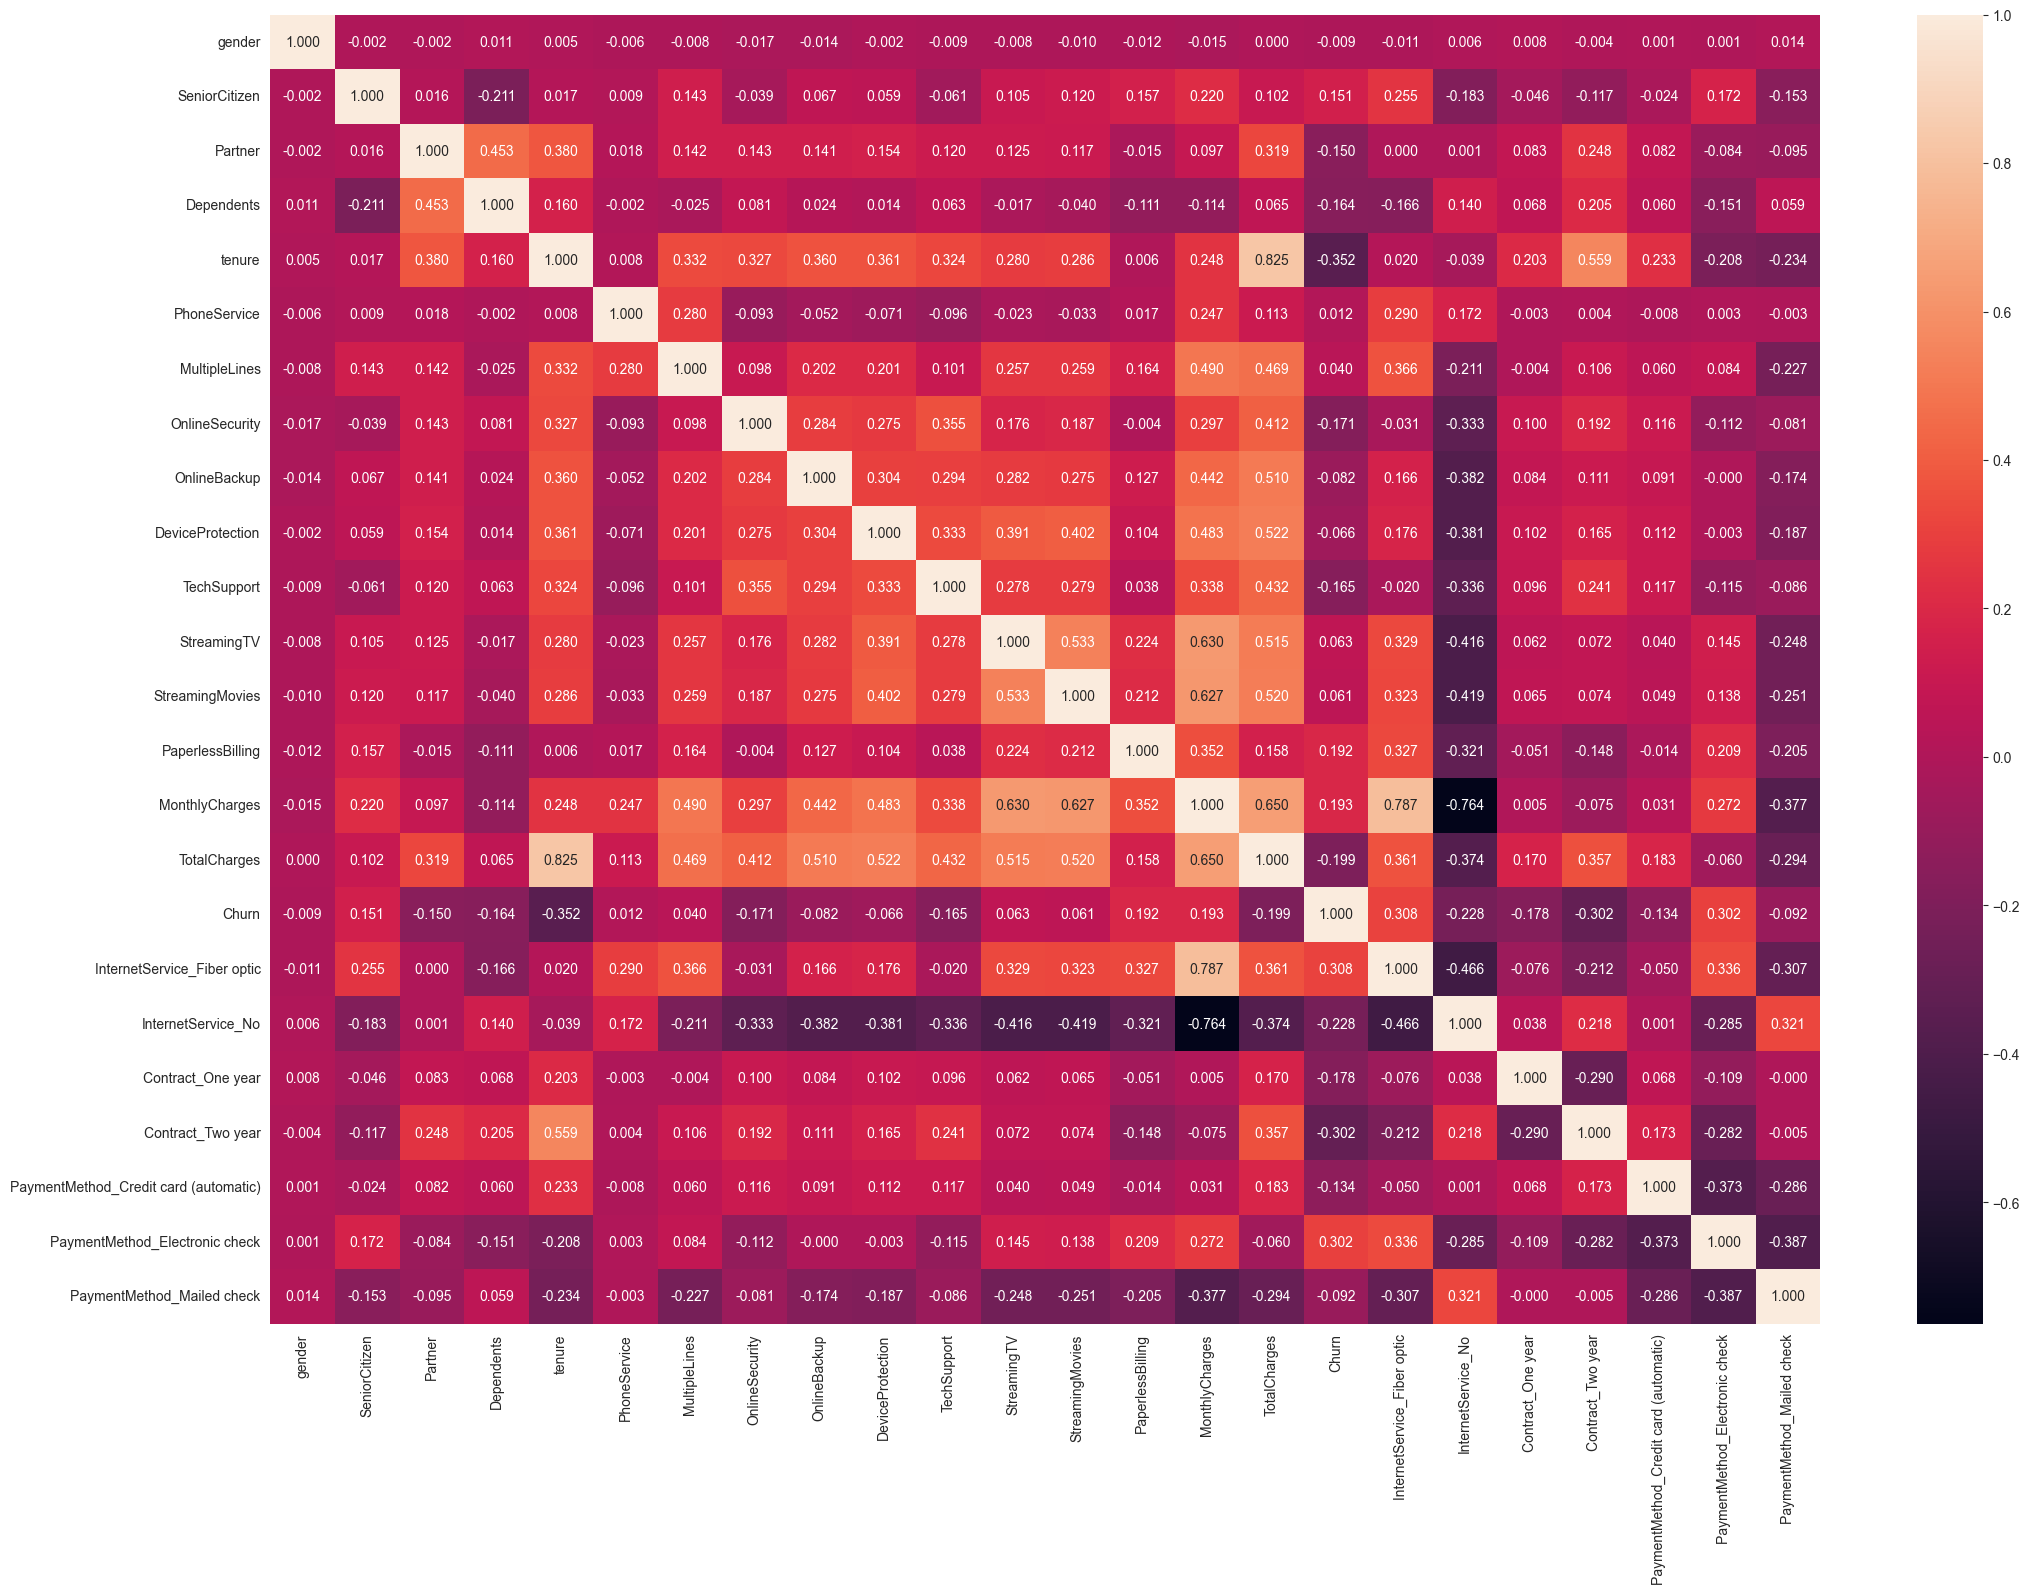

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = df.corr()

plt.figure(figsize=(25,17))
sns.heatmap(matrix, annot=True, fmt=".3f")
plt.show()

Получилось очень много колонок с низкой корреляцией с таргетом, уберём лишнее

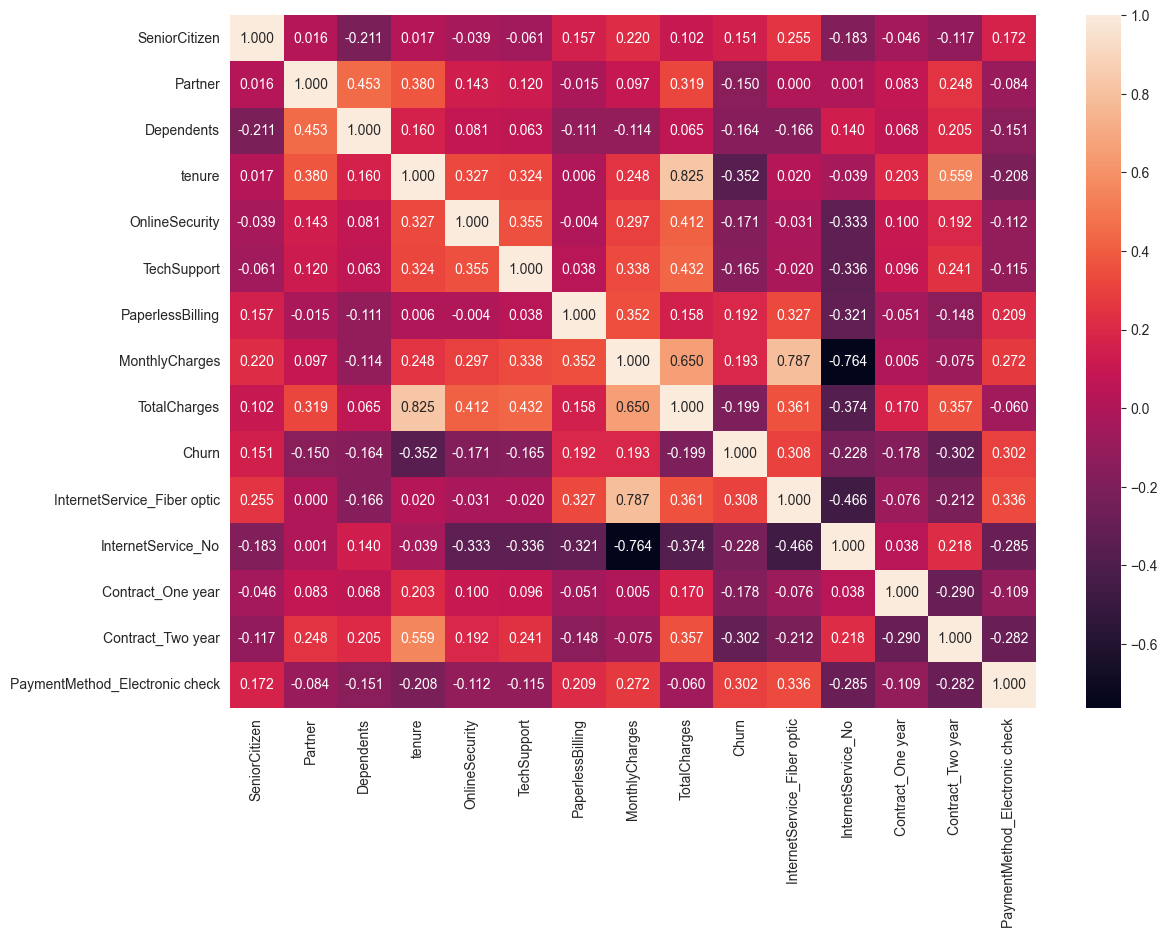

In [11]:
churn_corr = df.corr().abs()["Churn"]
feature_names = df.columns.drop("Churn")
cols_to_drop = churn_corr[feature_names][churn_corr[feature_names] < 0.15]

df.drop(cols_to_drop.index, inplace=True, axis=1)

plt.figure(figsize=(13, 9))
sns.heatmap(df.corr(), annot=True, fmt=".3f")
plt.show()

Также дропнем TotalCharges, чтобы сократить количество сильно взаимокоррелирующих признаков.

In [12]:
df.drop("TotalCharges", inplace=True, axis=1)

Выбранный подход энкодинга помимо своей основной задачи позволил выбросить много лишних колонок после фильтра по порогу корреляции.

# Перейдём к обучению моделей:
 - RandomForestClassifier
 - Градиентный бустинг (любой на выбор, не из sklearn)
 - SVC (classifier SVM)
 - KNeighborsClassifier

Для работы одного из бустингов требуется также установить библиотеку-зависимость libomp:
- Linux (частный случай для поднятия в docker compose):
```sh
    apk add libgomp
```
- MacOS:
```sh
    brew install libomp
```

In [13]:
# Импортируем все необходимые модели

# Random forest
from sklearn.ensemble import RandomForestClassifier

# GB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
"""Тут мог быть catboost, но он не захотел жить вместе с Python 3.14"""

# SVC
from sklearn.svm import SVC

# KNN
from sklearn.neighbors import KNeighborsClassifier

In [14]:
# А также импортируем всё для метрик
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

Поделим данные на train и test и создадим экземпляры наших моделей

In [15]:
from sklearn.model_selection import train_test_split

params = df.drop(columns=["Churn"])
target = df["Churn"]
params_train, params_test, target_train, target_test = train_test_split(
    params, target,
    test_size=0.2,
    stratify=target,
)

# много интересных параметров...
models = {
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
    ),
    "XGBClassifier": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="auc",
        n_jobs=-1,
    ),
    "LGBMClassifier": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        class_weight="balanced",
        eval_metric="auc",
        n_jobs=-1,
        verbose=-1,
    ),
    "SVC": SVC(
        probability=True,
        kernel="rbf"
    ),
    "KNeighborsClassifier": KNeighborsClassifier(
        n_neighbors=9,
        n_jobs=-1,
    )
}


Обучим модели и соберём метрики, сравним их!

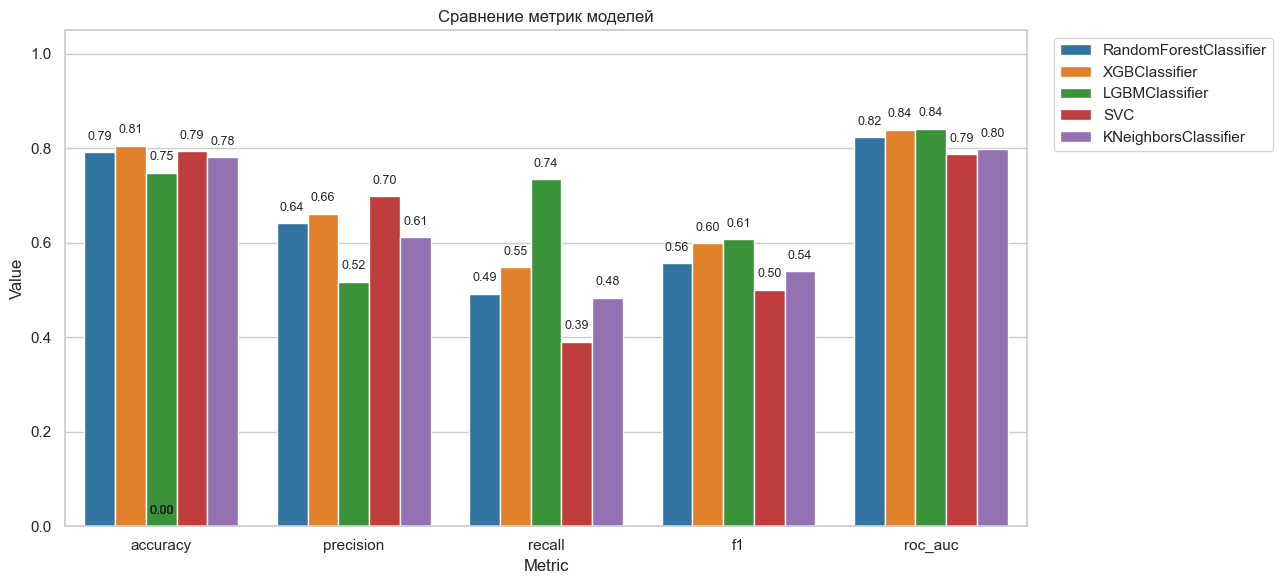

In [16]:
from math import ceil

results = []
target_predicts, target_probas = {}, {}

for name, model in models.items():
    model.fit(params_train, target_train)

    target_predict  = model.predict(params_test)
    target_proba  = model.predict_proba(params_test)[:, 1]

    target_predicts[name]  = target_predict
    target_probas[name] = target_proba

    results.append(
        dict(
            Model     = name,
            accuracy  = accuracy_score(target_test, target_predict),
            precision = precision_score(target_test, target_predict, zero_division=0),
            recall    = recall_score(target_test, target_predict, zero_division=0),
            f1        = f1_score(target_test, target_predict, zero_division=0),
            roc_auc   = roc_auc_score(target_test, target_proba),
        )
    )

metrics_df = pd.DataFrame(results)

sns.set_theme(style="whitegrid", palette="tab10")
metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=metrics_melted,
    x="Metric", y="Value", hue="Model"
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        x = p.get_x() + p.get_width() / 2,
        y = height + 0.02,
        s = f"{height:.2f}",
        ha = "center", va = "bottom", fontsize=9
    )

plt.title("Сравнение метрик моделей")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Анализ метрик показывает, что LGBM Classifier показывает превосходство при рассмотре всех метрик, однако имеет наименьший precision, что в некоторых случаях подводит. Наиболее сбалансированно показал себя бустинг XGB, стабильно удерживающий ТОП 2.

Summary: разные градиентные бустинги удобно использовать для любых задач, так как они довольно универсальны.
Для каких-то узконаправленных задач можно выбирать бустинг с отдельно настроенной конфигурацией.

В случае проблем с градиентами можно использовать и методы типо random forest или k nearest neighbors, так как они не так сильно уступают GB.

# Построим матрицы ошибок и ROC-кривые, для этого используем встроенные инструменты sklearn.

## Сравним Confusion matrix

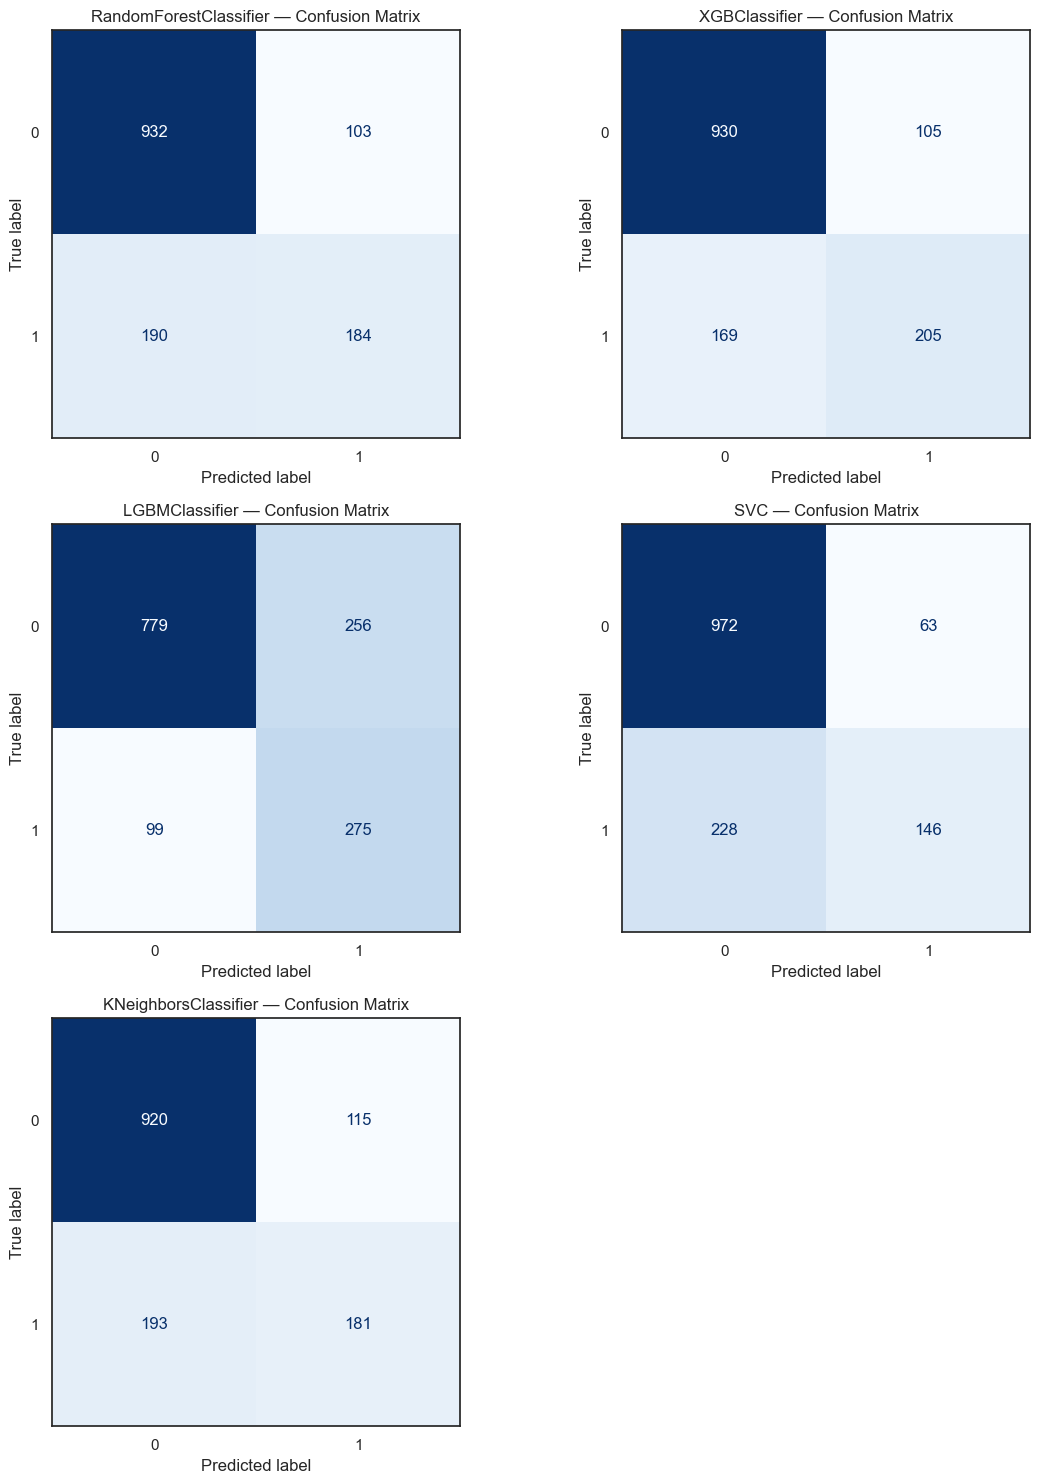

In [17]:
sns.set_theme(style="white")

idx = 0
n_models = len(models)
cols     = 2
rows     = ceil(n_models / cols)

fig_cm, axes_cm = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes_cm = axes_cm.flatten()

for idx, (name, ax) in enumerate(zip(models.keys(), axes_cm)):
    ConfusionMatrixDisplay.from_predictions(
        target_test,
        target_predicts[name],
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(f"{name} — Confusion Matrix")

for j in range(idx + 1, len(axes_cm)):
    axes_cm[j].set_visible(False)

fig_cm.tight_layout()


Как уже можно было заметить ранее LGBM Classifier имеет высший recall, поэтому и матрица ошибок у него тоже немного отличается по распределению.

В целом можно заметить тенденцию, что все остальные модели чаще ошибаются именно на положительных значениях, что соотвествует ранее рассмотренным метрикам.

## Сравним ROC curve моделей

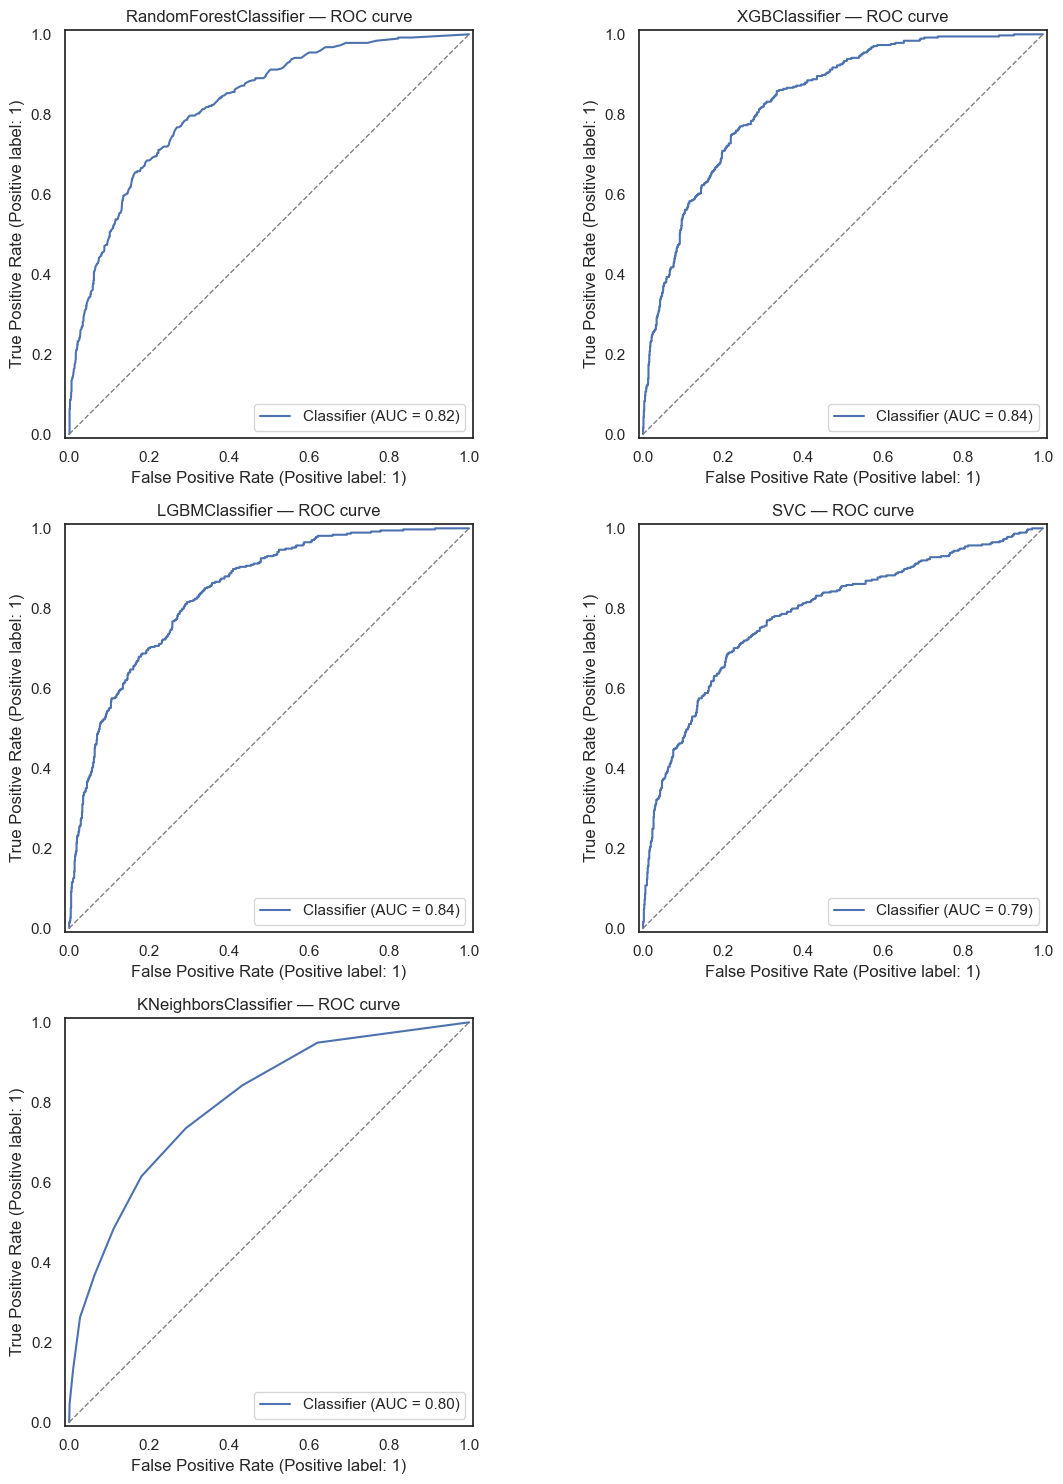

In [18]:
fig_roc, axes_roc = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes_roc = axes_roc.flatten()

for idx, (name, ax) in enumerate(zip(models.keys(), axes_roc)):
    RocCurveDisplay.from_predictions(
        target_test,
        target_probas[name],
        ax=ax
    )
    ax.set_title(f"{name} — ROC curve")
    ax.plot([0, 1], [0, 1], ls="--", lw=1, c="grey")

for j in range(idx + 1, len(axes_roc)):
    axes_roc[j].set_visible(False)

fig_roc.tight_layout()

Как было замечено мной ранее XGB Classifier действительно показал себя оптимально и занял лидирующую позицию по AUC. Стоит также заметить, что тот же Random forest дышит в спину градиентному бустингу и тоже применим.

# Выводы

Результаты показывают, что в данной задаче классификации всё-таки побеждает градиентный бустинг.
XGBClassifier тренируется чуть дольше остальных, однако показывает лучшие результаты.
Когда пропустить позитив дороже, чем поднять ложную тревогу лучше будет использовать LGBM: Лучший Recall (0.76), AUC 0.84; быстрее тренируется.

- $\textit{А также еще один вывод: мне надо изучать смысл метрик и метод работы моделей под капотом, чтобы лучше понимать что происходит :)}$